### 시설부하지수 (집중관리구역 설정 및 근거)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

In [10]:
merge_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")

In [11]:
merge_df.head()

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94


### 시설부하지수 분포 확인

분포 먼저 확인하는 이유는 20% 설정 값에 대한 근거를 싣기 위해.

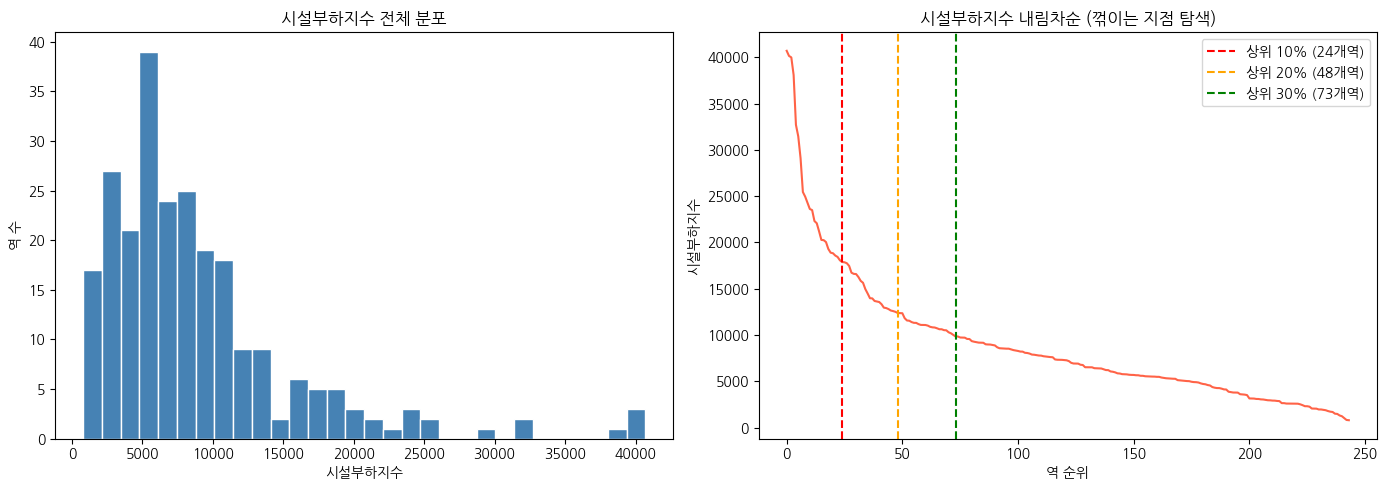

In [12]:
# 시설부하지수 분포 먼저 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 — 전체 분포
axes[0].hist(merge_df['시설부하지수'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('시설부하지수 전체 분포')
axes[0].set_xlabel('시설부하지수')
axes[0].set_ylabel('역 수')

# 내림차순 정렬 — 어디서 꺾이는지 확인
top_data = merge_df['시설부하지수'].sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(top_data.values, color='tomato')
axes[1].set_title('시설부하지수 내림차순 (꺾이는 지점 탐색)')
axes[1].set_xlabel('역 순위')
axes[1].set_ylabel('시설부하지수')

# 상위 10% / 20% / 30% 지점 수직선 표시
for pct, color in zip([10, 20, 30], ['red', 'orange', 'green']):
    idx = int(len(top_data) * pct / 100)
    axes[1].axvline(x=idx, color=color, linestyle='--', label=f'상위 {pct}% ({idx}개역)')

axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
# 컷오프별 기술통계 비교 — 숫자로 근거 만들기
print("=== 컷오프별 포함 역 수 및 평균 부하지수 ===\n")

for pct in [10, 15, 20, 25, 30]:
    threshold = merge_df['시설부하지수'].quantile(1 - pct/100)
    filtered = merge_df[merge_df['시설부하지수'] >= threshold]
    print(
        f"상위 {pct}% | 기준값: {threshold:.0f} | 역 수: {len(filtered)}개 "
        f"| 평균 부하지수: {filtered['시설부하지수'].mean():.0f} "
        f"| 1~4호선 비율: {(filtered['호선명'].isin(['1', '2', '3', '4']).sum() / len(filtered) * 100):.1f}%"
    )

=== 컷오프별 포함 역 수 및 평균 부하지수 ===

상위 10% | 기준값: 17869 | 역 수: 25개 | 평균 부하지수: 25198 | 1~4호선 비율: 76.0%
상위 15% | 기준값: 13960 | 역 수: 37개 | 평균 부하지수: 22271 | 1~4호선 비율: 67.6%
상위 20% | 기준값: 12364 | 역 수: 49개 | 평균 부하지수: 20018 | 1~4호선 비율: 63.3%
상위 25% | 기준값: 11025 | 역 수: 61개 | 평균 부하지수: 18343 | 1~4호선 비율: 59.0%
상위 30% | 기준값: 9857 | 역 수: 73개 | 평균 부하지수: 17067 | 1~4호선 비율: 53.4%


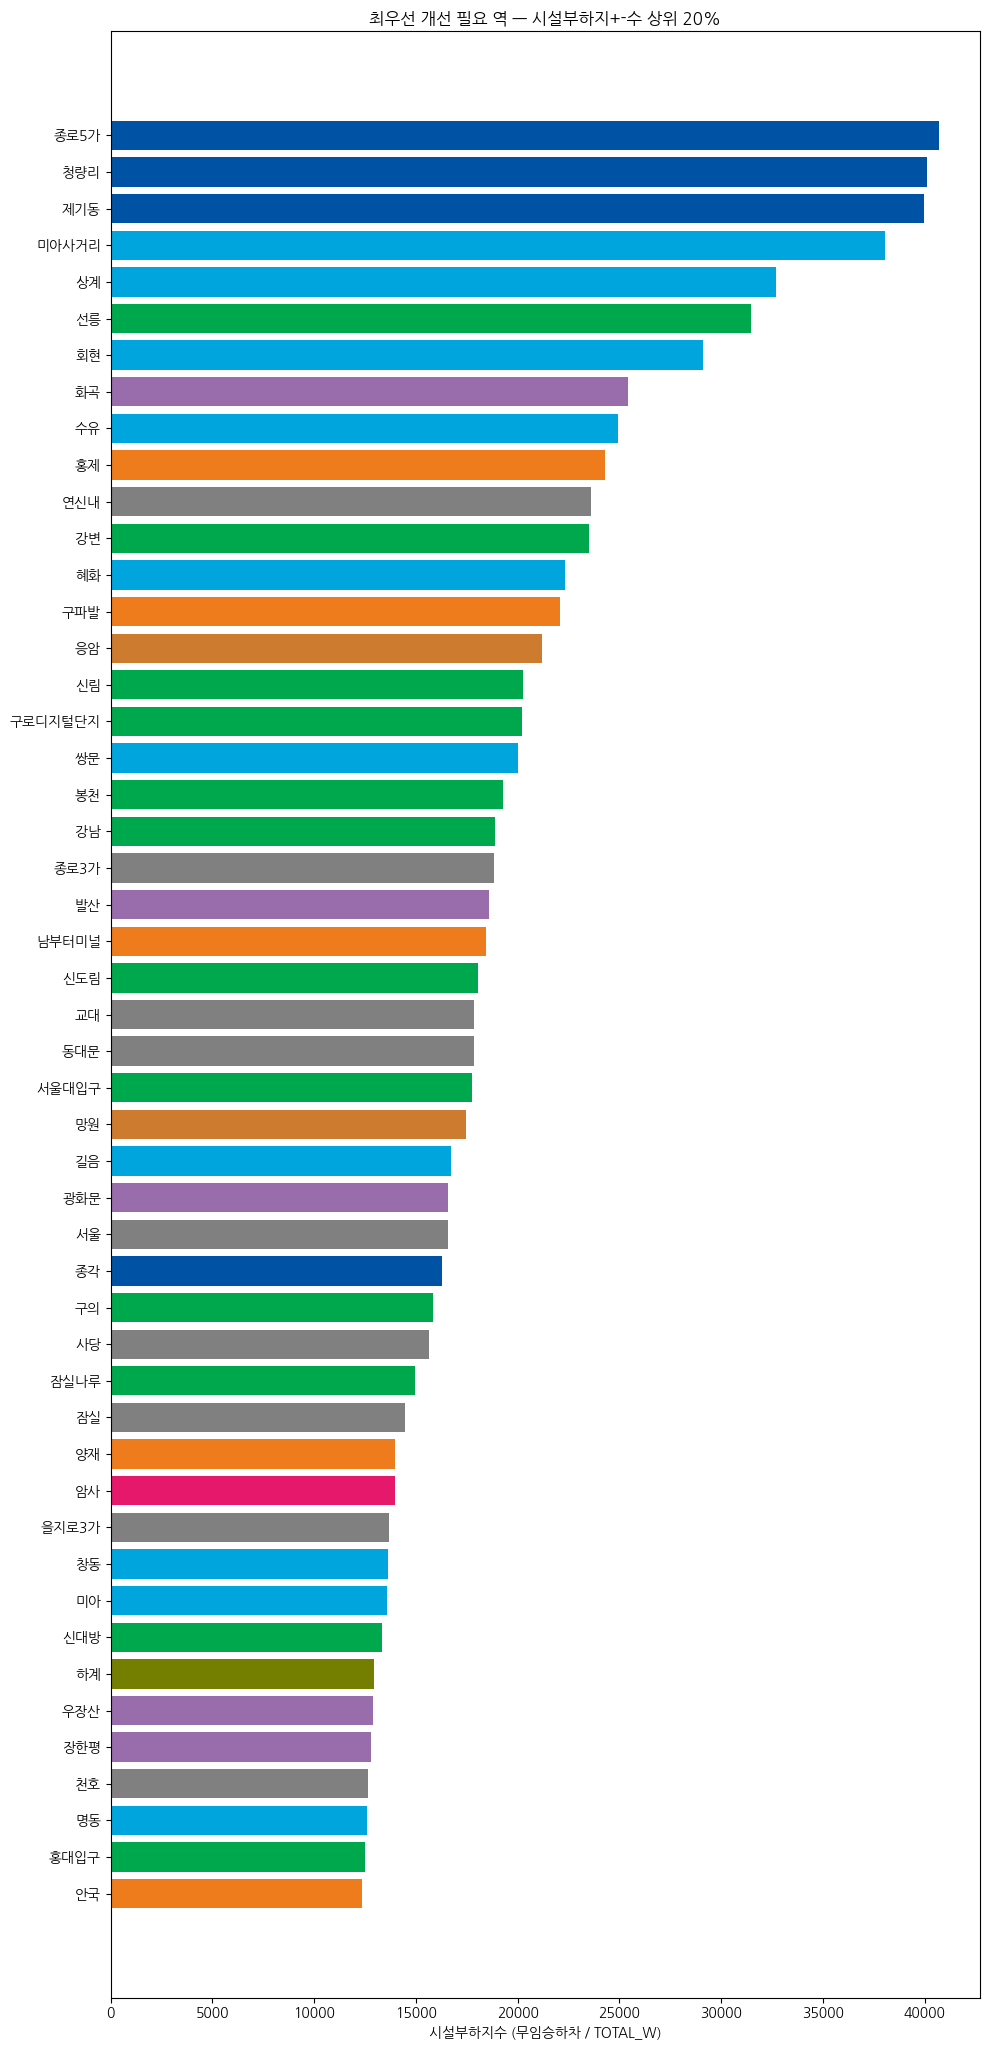

In [19]:
# 컷오프 결정 (예: 상위 20%)
cutoff_pct = 20
threshold = merge_df['시설부하지수'].quantile(1 - cutoff_pct/100)
priority = (
    merge_df[merge_df['시설부하지수'] >= threshold]
    .sort_values('시설부하지수', ascending=False)
    .copy()
)
# 호선명을 문자열로 통일 (int 타입이어도 매핑이 동작하도록)
LINE_COLOR_MAP = {
    '1': '#0052A4', '2': '#00A84D', '3': '#EF7C1C', '4': '#00A5DE',
    '5': '#996CAC', '6': '#CD7C2F', '7': '#747F00', '8': '#E6186C', '9': '#BDB092',
}

colors = priority['호선명'].astype(str).map(LINE_COLOR_MAP).fillna('gray')

# 가로 막대그래프
fig, ax = plt.subplots(figsize=(10, len(priority) * 0.4 + 1))

ax.barh(priority['지하철역'], priority['시설부하지수'], color=colors)
ax.set_xlabel('시설부하지수 (무임승하차 / TOTAL_W)')
ax.set_title(f'최우선 개선 필요 역 — 시설부하지+-수 상위 {cutoff_pct}%')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# priority 으로 저장
priority.to_csv('priority_area.csv', encoding='cp949', index=False)
print(f"저장 완료: {len(priority)}개 역")

저장 완료: 49개 역


### 분석 결론

시설부하지수(무임승하차 / TOTAL_W) 기준 상위 20%에 해당하는 49개 역을 최우선 개선 대상으로 선정하였다. 

상위 20% 기준은 분포 그래프에서 감소폭이 완만해지는 지점으로, 임의 설정이 아닌 데이터 기반으로 도출하였다.

시설부하지수 상위 역은 종로5가, 청량리, 제기동, 미아사거리 순으로 나타났으며, 이들은 교통약자 수요 대비 편의시설 공급이 가장 부족한 역에 해당한다.